# Case Studies: Out-of-Sample Transfer Predictions (17 Qualities)

Real-world examples of how the best model per quality predicts post-transfer performance for midfielders across four leagues.

All transfers below belong to the **2024 test set** — the models have **never seen** these observations during training.

In [71]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 130, "font.size": 9})

## 1 — Data & model setup

In [72]:
# ── Load ────────────────────────────────────────────────────────────────

DATA_DIR = "../../../../thesis_data/processed_data/thesis_model_dataset/active/"
df = pd.read_parquet(DATA_DIR + "within_league_transfers_v5.parquet")
mf = df[df["from_position"] == "Midfielder"].copy()

# Lookups
RAW = "../../../../thesis_data/raw_data/"
teams_df = pd.read_parquet(RAW + "Wyscout/wyscout_teams.parquet")
team_name = dict(zip(teams_df["team_id"], teams_df["name"]))

# ── Column groups ──────────────────────────────────────────────────────

QUALITIES = [
    "Active defence", "Aerial threat", "Box threat", "Composure",
    "Defensive heading", "Dribbling", "Effectiveness", "Finishing",
    "Hold-up play", "Intelligent defence", "Involvement",
    "Passing quality", "Pressing", "Progression",
    "Providing teammates", "Run quality", "Winning duels",
]

TEAM_Q = ["DEFENCE", "DEFENSIVE_TRANSITION", "ATTACKING_TRANSITION",
          "ATTACK", "PENETRATION", "CHANCE_CREATION", "OUTCOME"]

TEAM_Q_LABELS = ["Defence", "Def. Transition", "Att. Transition",
                 "Attack", "Penetration", "Chance Creation", "Outcome"]

from_pq = [f"from_{q}" for q in QUALITIES]
to_pq   = [f"to_{q}" for q in QUALITIES]
from_tq = [f"from_q_proj_{q}" for q in TEAM_Q]
to_tq   = [f"to_q_{q}" for q in TEAM_Q]

for q in TEAM_Q:
    mf[f"delta_team_{q}"] = mf[f"to_q_{q}"] - mf[f"from_q_proj_{q}"]
delta_tq = [f"delta_team_{q}" for q in TEAM_Q]

# ── Clean & split ─────────────────────────────────────────────────────

model_cols = from_pq + to_pq + from_tq + to_tq + delta_tq + ["from_season"]
mf_clean = mf[model_cols].dropna()

train = mf_clean[mf_clean["from_season"] <= 2023]
test  = mf_clean[mf_clean["from_season"] == 2024]

print(f"Train: {len(train):,}  |  Test: {len(test):,}")

Train: 4,383  |  Test: 465


In [73]:
# ── Best model per quality (from notebook 02) ─────────────────────────

BEST = {
    "Passing quality":      "3",
    "Involvement":          "3",
    "Providing teammates":  "3",
    "Progression":          "3",
    "Run quality":          "3",
    "Defensive heading":    "5",
    "Box threat":           "3",
    "Pressing":             "3",
    "Intelligent defence":  "3",
    "Active defence":       "5",
    "Effectiveness":        "3",
    "Aerial threat":        "3",
    "Winning duels":        "5",
    "Dribbling":            "3",
    "Hold-up play":         "3",
    "Composure":            "3",
    "Finishing":            "5",
}

fitted = {}
for q in QUALITIES:
    if BEST[q] == "3":
        feats = from_pq + from_tq + to_tq
        X = sm.add_constant(train[feats])
        y = train[f"to_{q}"]
        fitted[q] = {"model": sm.OLS(y, X).fit(), "feats": feats, "delta": False}
    else:
        feats = from_pq + delta_tq
        y = train[f"to_{q}"] - train[f"from_{q}"]
        X = sm.add_constant(train[feats])
        fitted[q] = {"model": sm.OLS(y, X).fit(), "feats": feats, "delta": True}

print(f"Trained {len(fitted)} quality-specific models.")

Trained 17 quality-specific models.


In [74]:
# ── Prediction helper ─────────────────────────────────────────────────

def predict_transfer(idx, qualities=None):
    """Return a DataFrame with Pre / Predicted / Actual for each quality."""
    if qualities is None:
        qualities = QUALITIES
    row = mf_clean.loc[idx]
    records = []
    for q in qualities:
        info = fitted[q]
        X = sm.add_constant(
            pd.DataFrame([row[info["feats"]].values], columns=info["feats"]),
            has_constant="add",
        )
        pred = info["model"].predict(X)[0]
        if info["delta"]:
            pred = float(row[f"from_{q}"]) + pred
        records.append({
            "Quality": q,
            "Pre": float(row[f"from_{q}"]),
            "Predicted": pred,
            "Actual": float(row[f"to_{q}"]),
        })
    out = pd.DataFrame(records).set_index("Quality")
    out["Error"] = out["Predicted"] - out["Actual"]
    return out

In [75]:
# ── Visualisation helpers ─────────────────────────────────────────────

def plot_team_context(idx, title):
    """Dumbbell chart: origin vs destination team qualities on a z-score axis."""
    row = mf.loc[idx]
    from_vals = [float(row[c]) for c in from_tq]
    to_vals   = [float(row[c]) for c in to_tq]

    y = np.arange(len(TEAM_Q_LABELS))

    fig, ax = plt.subplots(figsize=(7, 3.5))

    # Connecting lines
    for i in range(len(y)):
        ax.plot([from_vals[i], to_vals[i]], [y[i], y[i]],
                color="#bdc3c7", linewidth=1.5, zorder=1)

    # Markers
    ax.scatter(from_vals, y, color="#e74c3c", s=70, zorder=2, label="Origin team")
    ax.scatter(to_vals,   y, color="#3498db", s=70, zorder=2, label="Destination team")

    ax.axvline(0, color="grey", linewidth=0.5, linestyle="--")
    ax.set_yticks(y)
    ax.set_yticklabels(TEAM_Q_LABELS)
    ax.set_xlabel("Team quality (z-score)")
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.legend(loc="lower right", fontsize=8)
    fig.tight_layout()
    plt.show()


def _radar_axes(ax, labels):
    """Configure polar axes for a radar chart."""
    n = len(labels)
    angles = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
    angles += angles[:1]
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=6.5)
    ax.set_ylim(-2.0, 2.0)
    ax.set_yticks([-1, 0, 1])
    ax.set_yticklabels(["-1", "0", "+1"], fontsize=6, color="grey")
    ax.grid(color="lightgrey", linewidth=0.4)
    return angles


def plot_radars(result, title):
    """Side-by-side radar charts: pre (left) and predicted vs actual (right)."""
    labels = result.index.tolist()
    pre_vals    = result["Pre"].values.tolist()       + [result["Pre"].values[0]]
    pred_vals   = result["Predicted"].values.tolist() + [result["Predicted"].values[0]]
    actual_vals = result["Actual"].values.tolist()    + [result["Actual"].values[0]]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6),
                                    subplot_kw={"projection": "polar"})

    # Left: pre-transfer
    angles = _radar_axes(ax1, labels)
    ax1.plot(angles, pre_vals, linewidth=1.5, color="#bdc3c7", label="Pre-transfer")
    ax1.fill(angles, pre_vals, alpha=0.15, color="#bdc3c7")
    ax1.set_title("Pre-transfer profile", fontsize=10, fontweight="bold", pad=20)
    ax1.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=8)

    # Right: predicted vs actual
    angles = _radar_axes(ax2, labels)
    ax2.plot(angles, actual_vals, linewidth=1.5, color="#2ecc71", label="Actual post")
    ax2.fill(angles, actual_vals, alpha=0.10, color="#2ecc71")
    ax2.plot(angles, pred_vals, linewidth=1.5, color="#3498db", linestyle="--", label="Predicted post")
    ax2.fill(angles, pred_vals, alpha=0.10, color="#3498db")
    ax2.set_title("Predicted vs Actual post-transfer", fontsize=10, fontweight="bold", pad=20)
    ax2.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=8)

    fig.suptitle(title, fontsize=12, fontweight="bold", y=1.02)
    fig.tight_layout()
    plt.show()

---
## 2 — Out-of-sample case studies (test set, 2024)

| Player | League | Transfer | Fee |
|--------|--------|----------|-----|
| Valentin Rongier | Ligue 1 | Marseille → Rennes | €5.5 M |
| Mahdi Camara | Ligue 1 | Brest → Rennes | €8.0 M |
| Fernando Beltrán | Liga MX | Guadalajara → León | €2.6 M |
| Jesús Güemez | Liga MX | Atl. San Luis → Santos Laguna | Free |
| Samuel Holm | Allsvenskan | Djurgården → Häcken | €0.4 M |
| Daniel Ask | Allsvenskan | Västerås → Öster | Free |
| Nicolai Remberg | 2. Bundesliga | Holstein Kiel → Hamburger SV | €2.4 M |

In [76]:
CASES = [
    {"wy_id": 260002, "name": "Valentin Rongier",  "league": "Ligue 1"},
    {"wy_id": 426712, "name": "Mahdi Camara",       "league": "Ligue 1"},
    {"wy_id": 512649, "name": "Fernando Beltrán",   "league": "Liga MX"},
    {"wy_id": 113734, "name": "Jesús Güemez",       "league": "Liga MX"},
    {"wy_id": 367395, "name": "Samuel Holm",        "league": "Allsvenskan"},
    {"wy_id": 428282, "name": "Daniel Ask",         "league": "Allsvenskan"},
    {"wy_id": 577008, "name": "Nicolai Remberg",    "league": "2. Bundesliga"},
]

case_rows = {}
for c in CASES:
    orig = mf[(mf["wy_player_id"] == c["wy_id"]) & (mf["from_season"] == 2024)]
    assert len(orig) > 0, f"{c['name']}: not found in 2024"
    idx = orig.iloc[-1].name
    assert idx in mf_clean.index, f"{c['name']}: dropped during cleaning"
    case_rows[c["wy_id"]] = idx
    meta = mf.loc[idx]
    print(
        f"{c['name']:25s}  [{c['league']:15s}]  "
        f"{team_name.get(meta['from_team_id'], '?'):25s} → "
        f"{team_name.get(meta['to_team_id'], '?'):25s}  "
        f"Age {meta['player_season_age']:.1f}"
    )

Valentin Rongier           [Ligue 1        ]  Olympique Marseille       → Rennes                     Age 29.7
Mahdi Camara               [Ligue 1        ]  Brest                     → Rennes                     Age 26.1
Fernando Beltrán           [Liga MX        ]  Guadalajara               → León                       Age 26.2
Jesús Güemez               [Liga MX        ]  Atlético de San Luis      → Santos Laguna              Age 32.7
Samuel Holm                [Allsvenskan    ]  Djurgården                → Häcken                     Age 26.5
Daniel Ask                 [Allsvenskan    ]  Västerås SK               → Öster                      Age 25.3
Nicolai Remberg            [2. Bundesliga  ]  Holstein Kiel             → Hamburger SV               Age 24.2


In [77]:
def show_case(wy_id, name, league):
    idx = case_rows[wy_id]
    plot_team_context(idx, f"Team Context — {name}")
    res = predict_transfer(idx)
    plot_radars(res, name)
    print(f"MAE: {res['Error'].abs().mean():.3f}")
    display(res.round(3))
    return res

---
### 2.1 — Ligue 1

#### Valentin Rongier: Marseille → Rennes

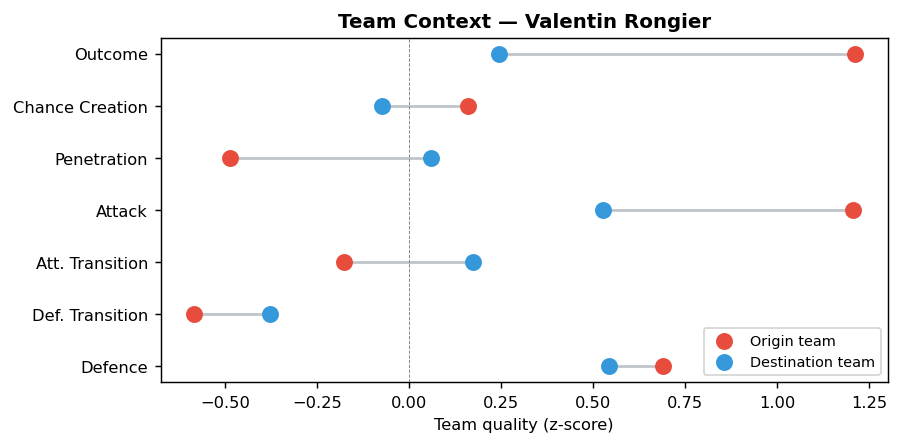

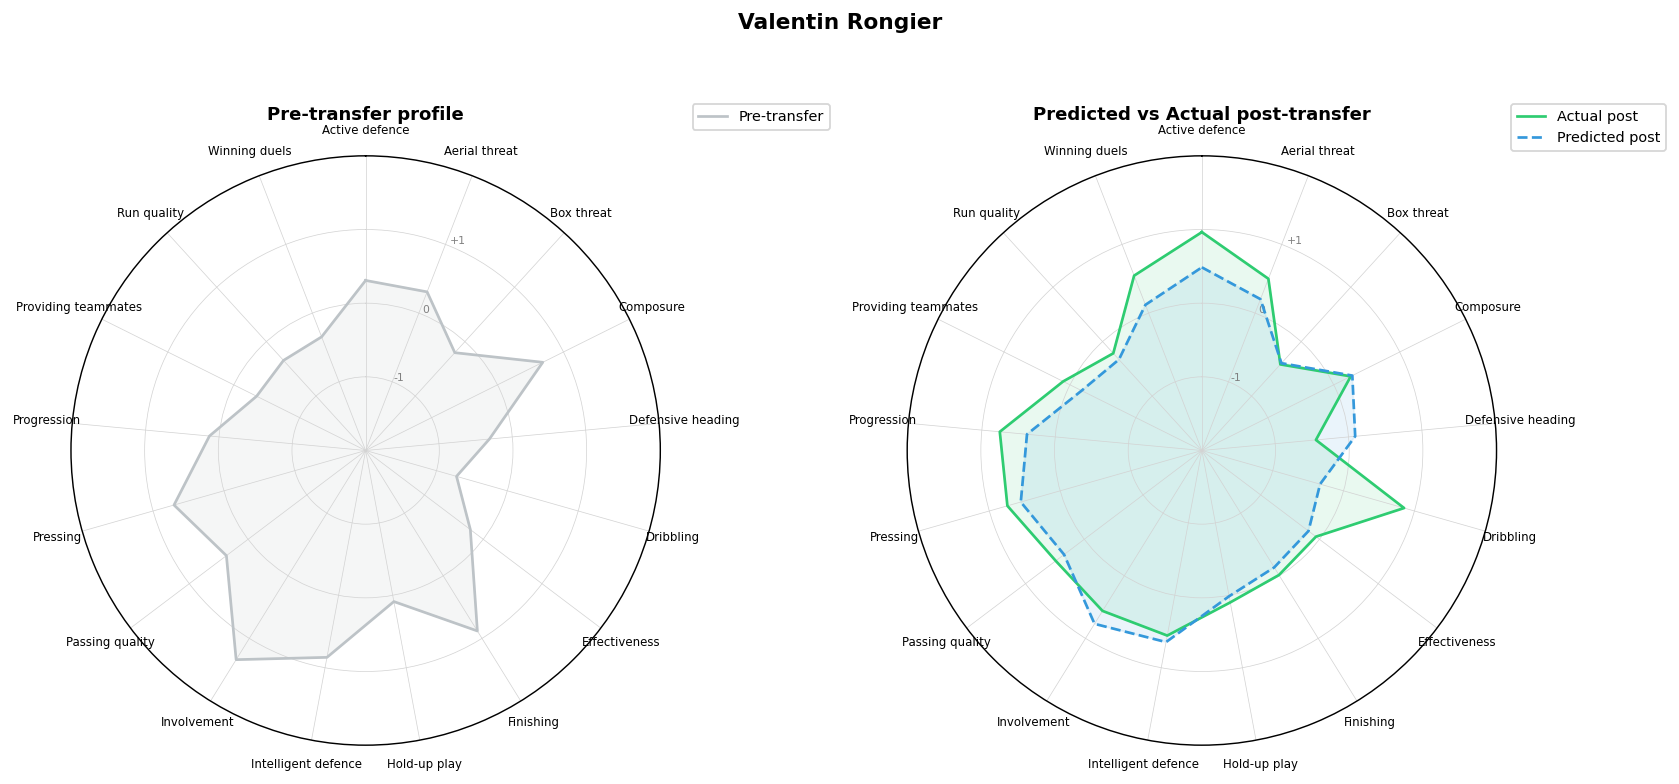

MAE: 0.276


,Pre,Predicted,Actual,Error
Quality,,,,
Active defence,0.308,0.486,0.964,-0.478
Aerial threat,0.309,0.203,0.500,-0.297
Box threat,-0.203,-0.396,-0.418,0.022
Composure,0.686,0.282,0.257,0.024
Defensive heading,-0.313,0.090,-0.445,0.535
Dribbling,-0.717,-0.331,0.854,-1.186
Effectiveness,-0.219,-0.186,-0.059,-0.127
Finishing,0.881,-0.134,-0.012,-0.122
Hold-up play,0.086,0.013,0.098,-0.085


In [78]:
rongier = show_case(260002, "Valentin Rongier", "Ligue 1")

#### Mahdi Camara: Brest → Rennes

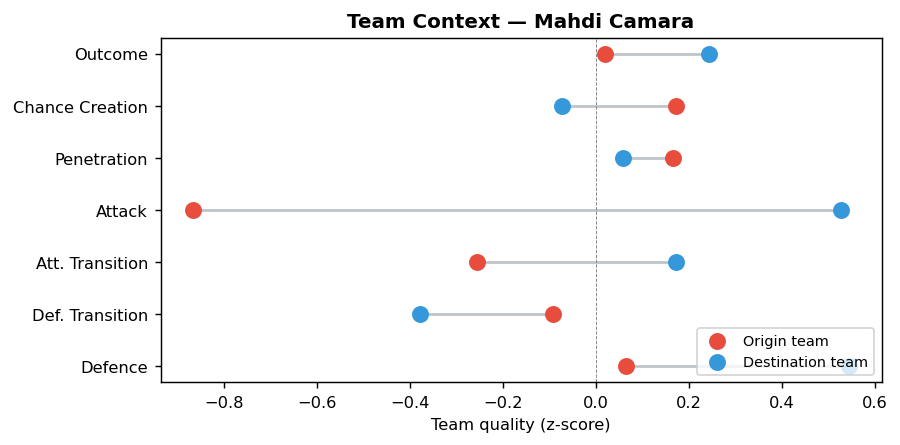

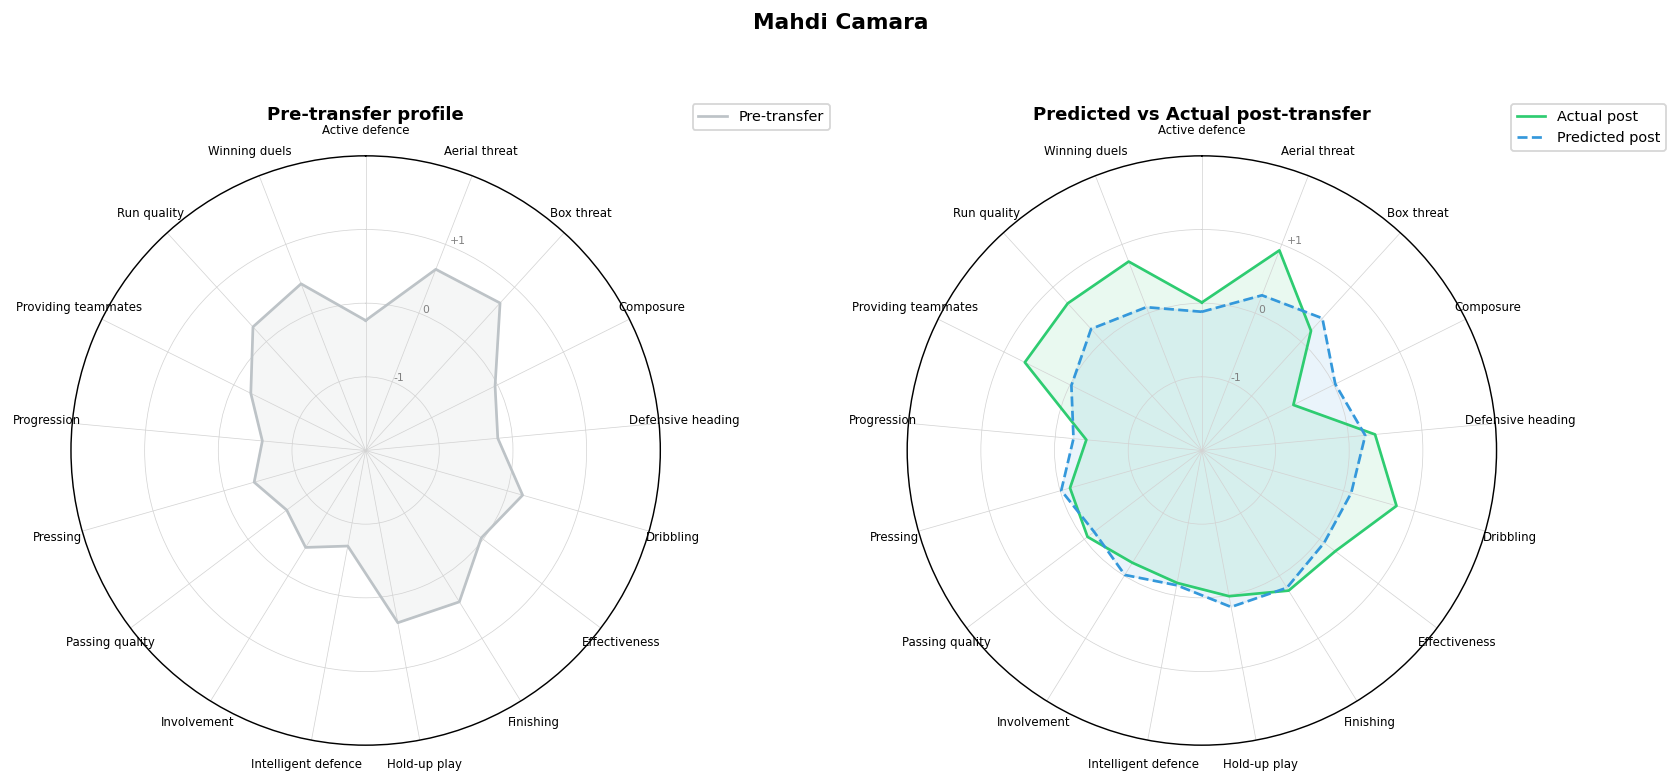

MAE: 0.311


,Pre,Predicted,Actual,Error
Quality,,,,
Active defence,-0.235,-0.117,0.010,-0.126
Aerial threat,0.638,0.259,0.913,-0.654
Box threat,0.709,0.429,0.199,0.230
Composure,-0.037,0.023,-0.612,0.636
Defensive heading,-0.199,0.227,0.361,-0.134
Dribbling,0.216,0.108,0.747,-0.639
Effectiveness,-0.032,0.080,0.269,-0.189
Finishing,0.416,0.192,0.237,-0.045
Hold-up play,0.379,0.161,0.012,0.148


In [79]:
camara = show_case(426712, "Mahdi Camara", "Ligue 1")

---
### 2.2 — Liga MX

#### Fernando Beltrán: Guadalajara → León

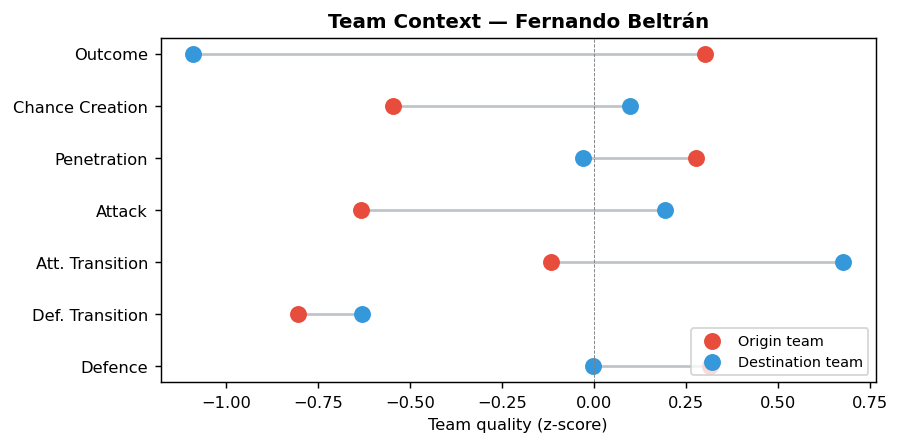

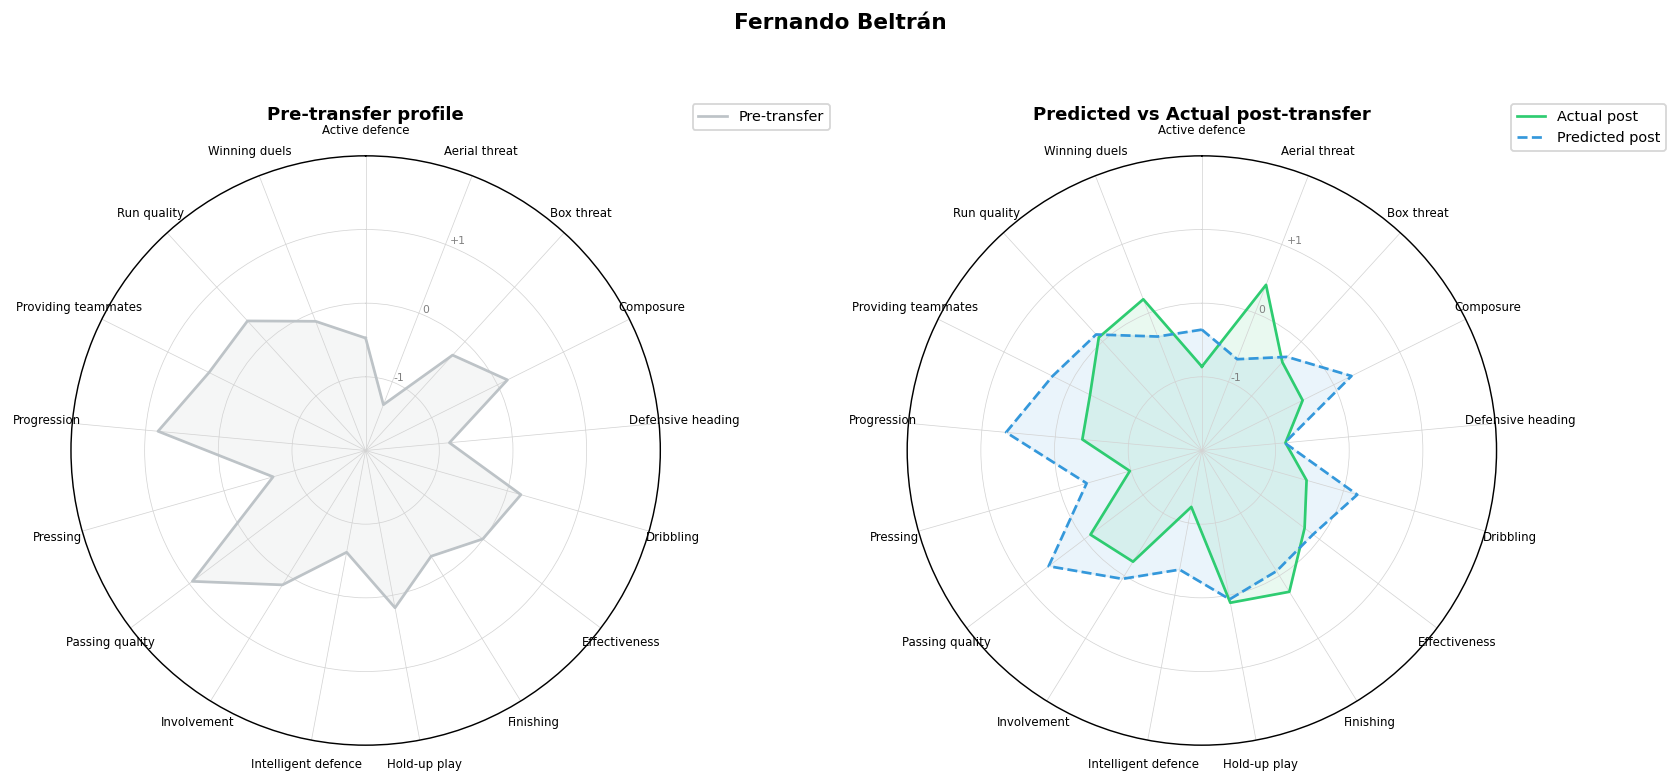

MAE: 0.490


,Pre,Predicted,Actual,Error
Quality,,,,
Active defence,-0.474,-0.359,-0.861,0.501
Aerial threat,-1.333,-0.671,0.412,-1.083
Box threat,-0.248,-0.280,-0.378,0.098
Composure,0.150,0.269,-0.472,0.740
Defensive heading,-0.857,-0.871,-0.860,-0.011
Dribbling,0.192,0.193,-0.522,0.715
Effectiveness,-0.007,-0.109,-0.252,0.143
Finishing,-0.312,-0.074,0.256,-0.330
Hold-up play,0.172,0.055,0.102,-0.048


In [80]:
beltran = show_case(512649, "Fernando Beltrán", "Liga MX")

#### Jesús Güemez: Atl. San Luis → Santos Laguna

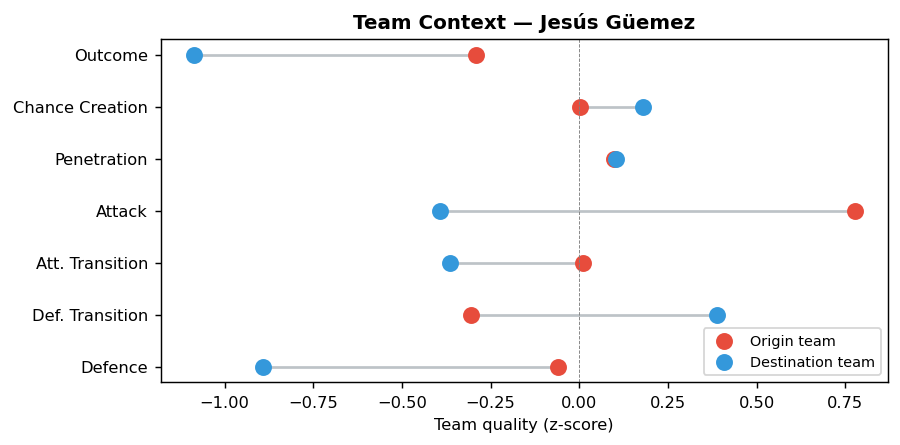

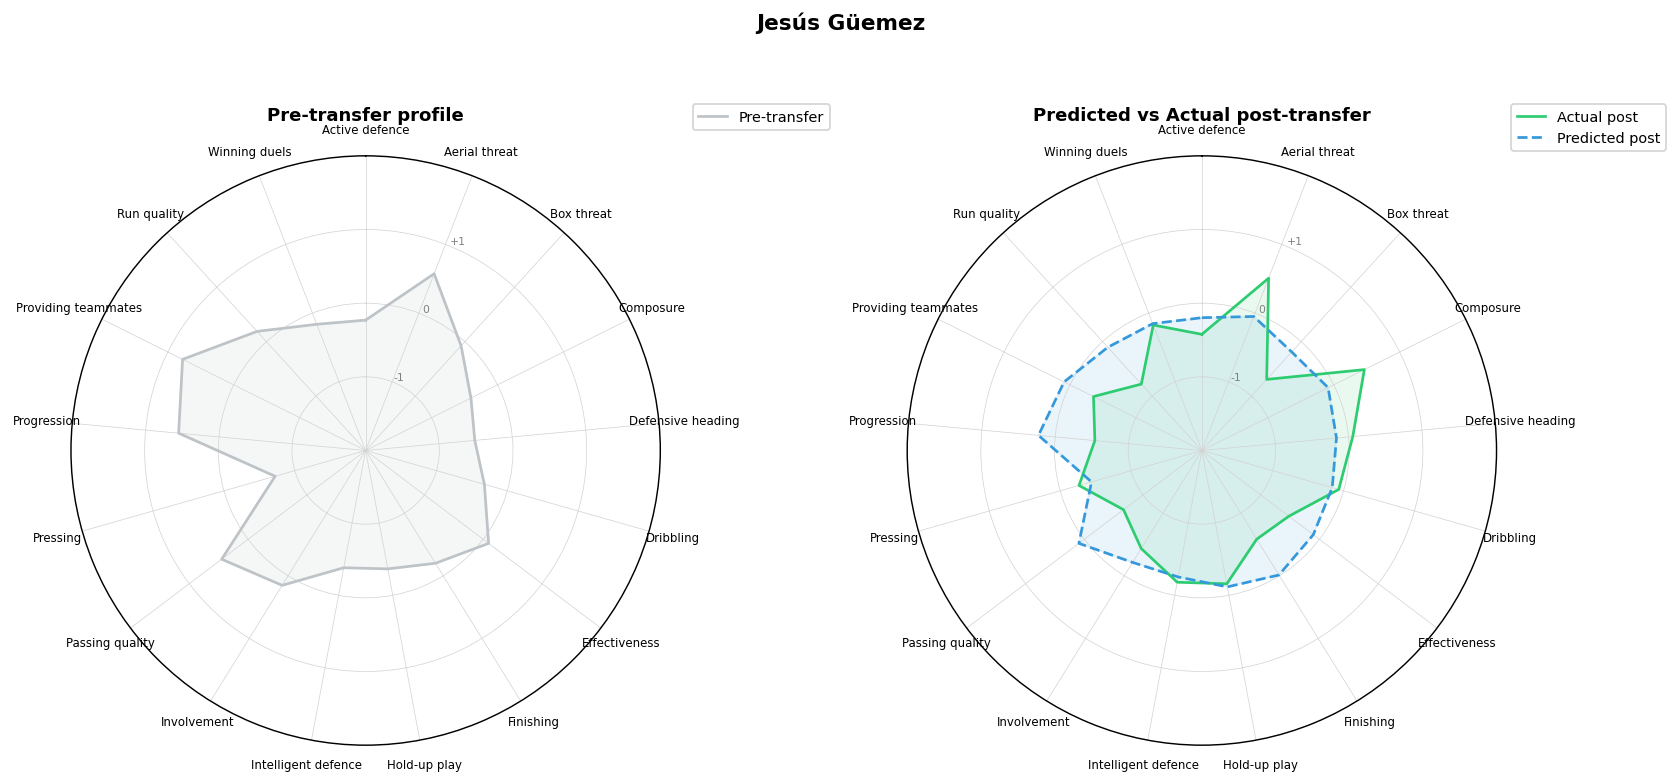

MAE: 0.372


,Pre,Predicted,Actual,Error
Quality,,,,
Active defence,-0.230,-0.197,-0.423,0.226
Aerial threat,0.574,-0.049,0.509,-0.558
Box threat,-0.076,-0.189,-0.694,0.504
Composure,-0.403,-0.086,0.464,-0.549
Defensive heading,-0.512,-0.165,0.058,-0.223
Dribbling,-0.324,-0.160,-0.068,-0.092
Effectiveness,0.092,-0.104,-0.520,0.416
Finishing,-0.200,-0.012,-0.585,0.572
Hold-up play,-0.365,-0.116,-0.159,0.042


In [81]:
guemez = show_case(113734, "Jesús Güemez", "Liga MX")

---
### 2.3 — Allsvenskan

#### Samuel Holm: Djurgården → Häcken

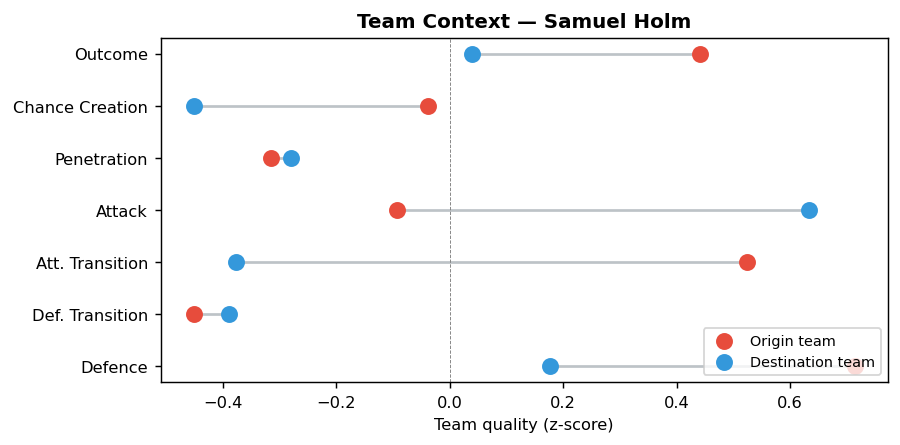

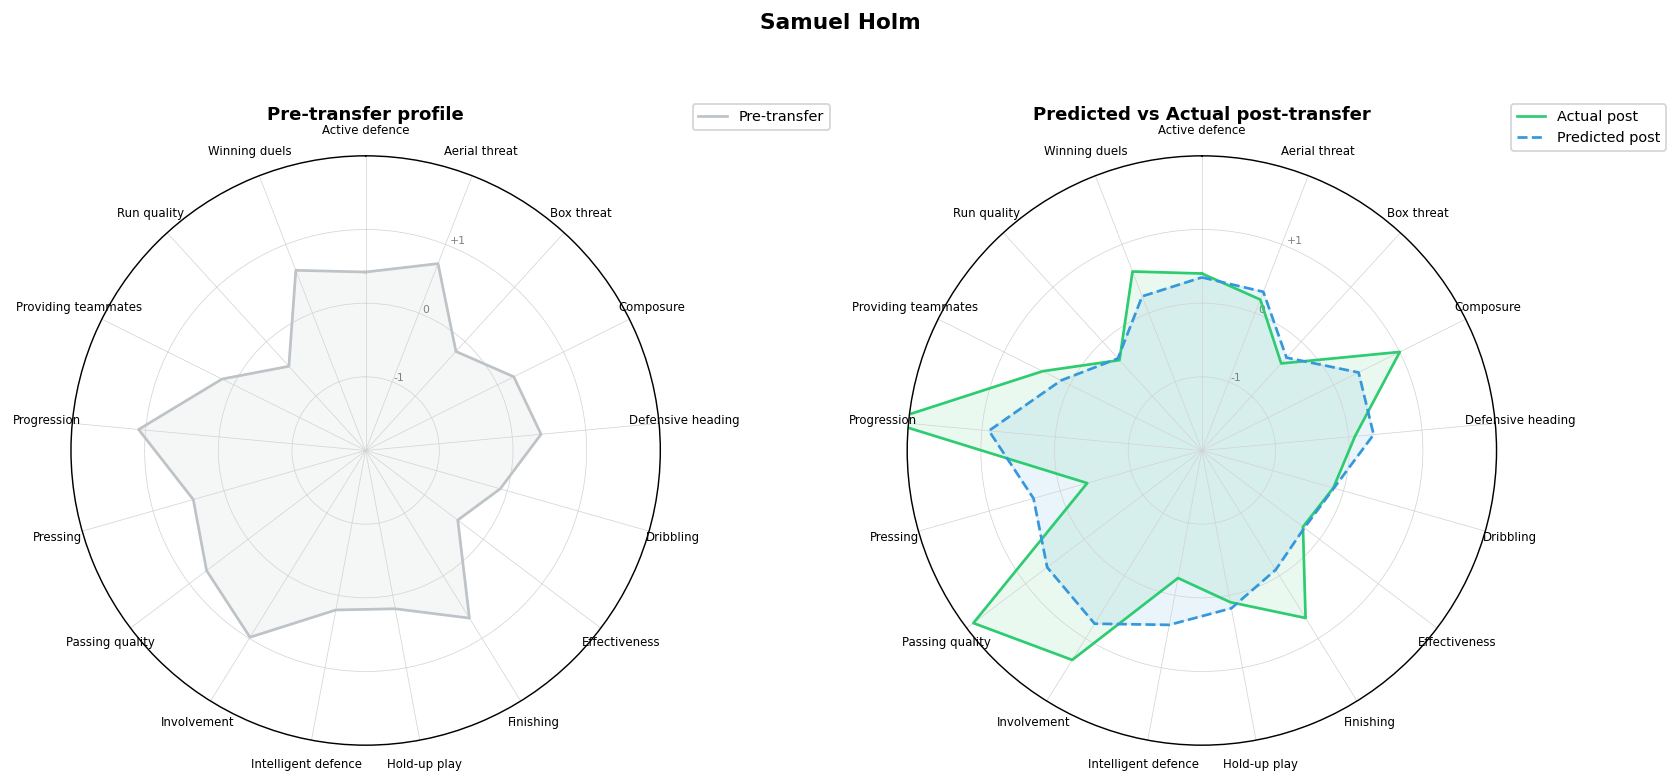

MAE: 0.431


,Pre,Predicted,Actual,Error
Quality,,,,
Active defence,0.423,0.350,0.403,-0.052
Aerial threat,0.721,0.310,0.197,0.113
Box threat,-0.180,-0.294,-0.401,0.107
Composure,0.246,0.377,1.002,-0.625
Defensive heading,0.391,0.341,0.087,0.254
Dribbling,-0.100,-0.137,-0.145,0.008
Effectiveness,-0.433,-0.257,-0.281,0.024
Finishing,0.676,-0.096,0.674,-0.770
Hold-up play,0.186,0.179,0.094,0.084


In [82]:
holm = show_case(367395, "Samuel Holm", "Allsvenskan")

#### Daniel Ask: Västerås → Öster

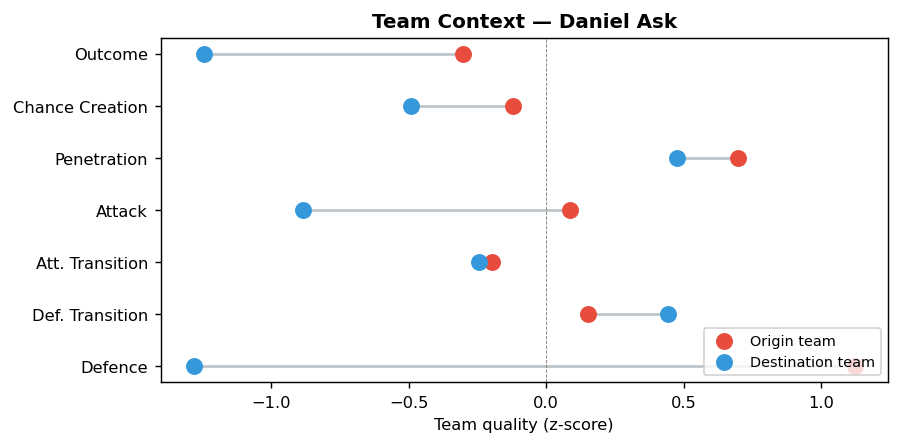

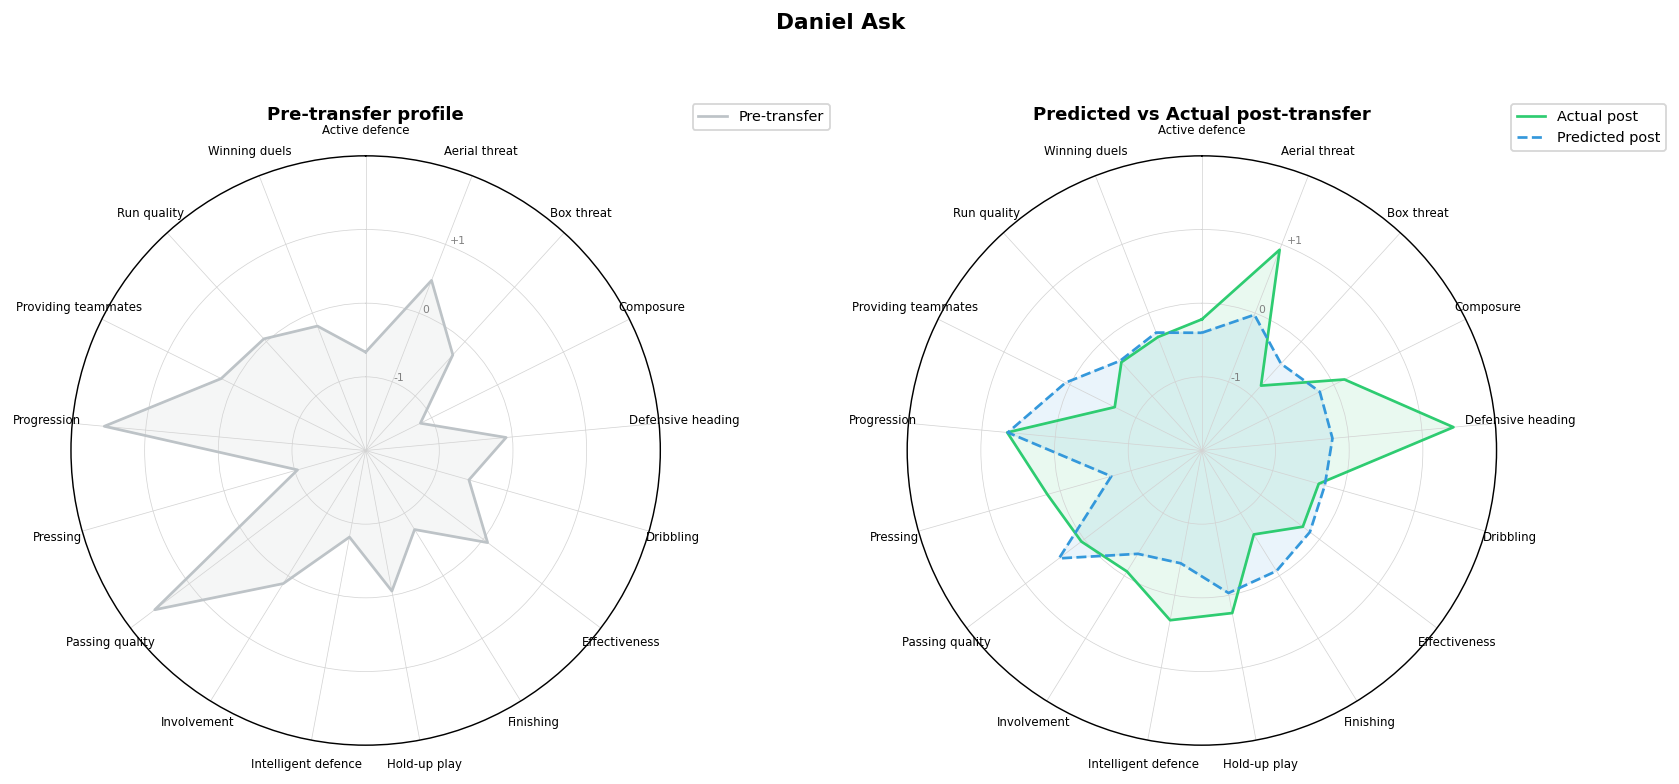

MAE: 0.460


,Pre,Predicted,Actual,Error
Quality,,,,
Active defence,-0.664,-0.402,-0.219,-0.183
Aerial threat,0.476,-0.024,0.922,-0.947
Box threat,-0.243,-0.406,-0.808,0.402
Composure,-1.169,-0.212,0.163,-0.374
Defensive heading,-0.085,-0.220,1.430,-1.650
Dribbling,-0.542,-0.265,-0.351,0.085
Effectiveness,0.075,-0.163,-0.283,0.120
Finishing,-0.738,-0.076,-0.660,0.584
Hold-up play,-0.059,-0.032,0.245,-0.277


In [83]:
ask = show_case(428282, "Daniel Ask", "Allsvenskan")

---
### 2.4 — 2. Bundesliga

#### Nicolai Remberg: Holstein Kiel → Hamburger SV

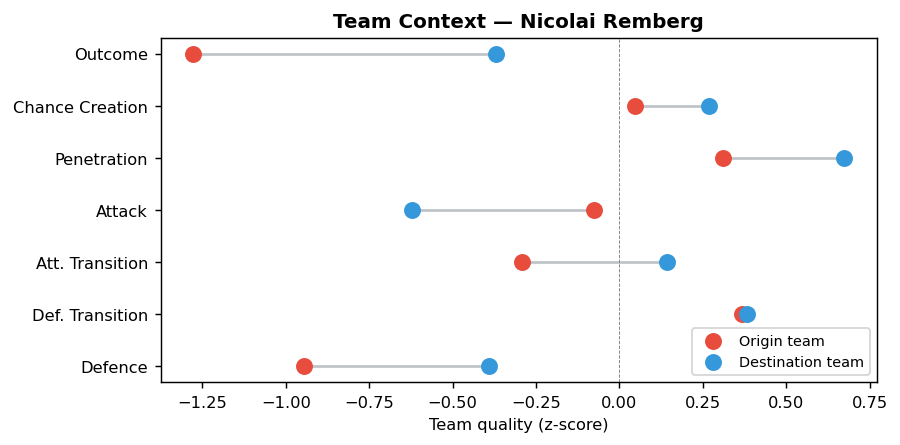

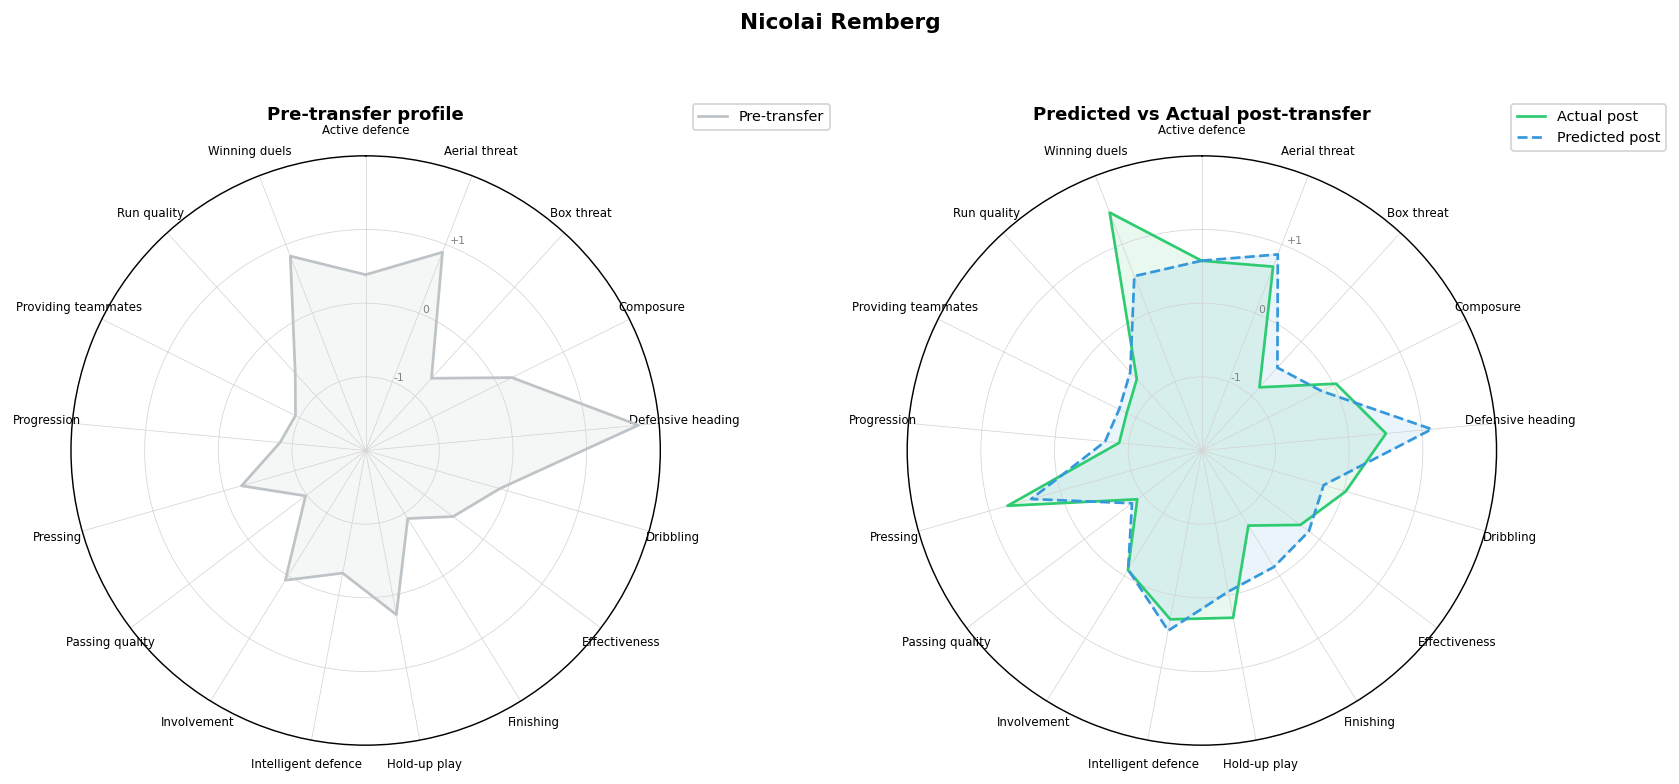

MAE: 0.283


,Pre,Predicted,Actual,Error
Quality,,,,
Active defence,0.386,0.577,0.575,0.002
Aerial threat,0.887,0.854,0.677,0.177
Box threat,-0.673,-0.478,-0.839,0.361
Composure,0.220,-0.188,0.035,-0.222
Defensive heading,1.719,1.134,0.510,0.624
Dribbling,-0.108,-0.282,0.030,-0.312
Effectiveness,-0.511,-0.180,-0.324,0.143
Finishing,-0.914,-0.141,-0.801,0.660
Hold-up play,0.268,-0.051,0.310,-0.361


In [84]:
remberg = show_case(577008, "Nicolai Remberg", "2. Bundesliga")

---
## 3 — Summary

In [85]:
summary_rows = []
for c in CASES:
    res = predict_transfer(case_rows[c["wy_id"]])
    meta = mf.loc[case_rows[c["wy_id"]]]
    summary_rows.append({
        "Player": c["name"],
        "League": c["league"],
        "Transfer": f"{team_name.get(meta['from_team_id'], '?')} → {team_name.get(meta['to_team_id'], '?')}",
        "MAE": res["Error"].abs().mean(),
        "Median AE": res["Error"].abs().median(),
        "Max |Error|": res["Error"].abs().max(),
        "Worst quality": res["Error"].abs().idxmax(),
    })

summary = pd.DataFrame(summary_rows).set_index("Player")
summary.round(3)

,League,Transfer,MAE,Median AE,Max |Error|,Worst quality
Player,,,,,,
Valentin Rongier,Ligue 1,Olympique Marseille → Rennes,0.276,0.189,1.186,Dribbling
Mahdi Camara,Ligue 1,Brest → Rennes,0.311,0.189,0.706,Providing teammates
Fernando Beltrán,Liga MX,Guadalajara → León,0.490,0.543,1.083,Aerial threat
Jesús Güemez,Liga MX,Atlético de San Luis → Santos Laguna,0.372,0.416,0.769,Progression
Samuel Holm,Allsvenskan,Djurgården → Häcken,0.431,0.280,1.383,Progression
Daniel Ask,Allsvenskan,Västerås SK → Öster,0.460,0.374,1.650,Defensive heading
Nicolai Remberg,2. Bundesliga,Holstein Kiel → Hamburger SV,0.283,0.192,0.926,Winning duels


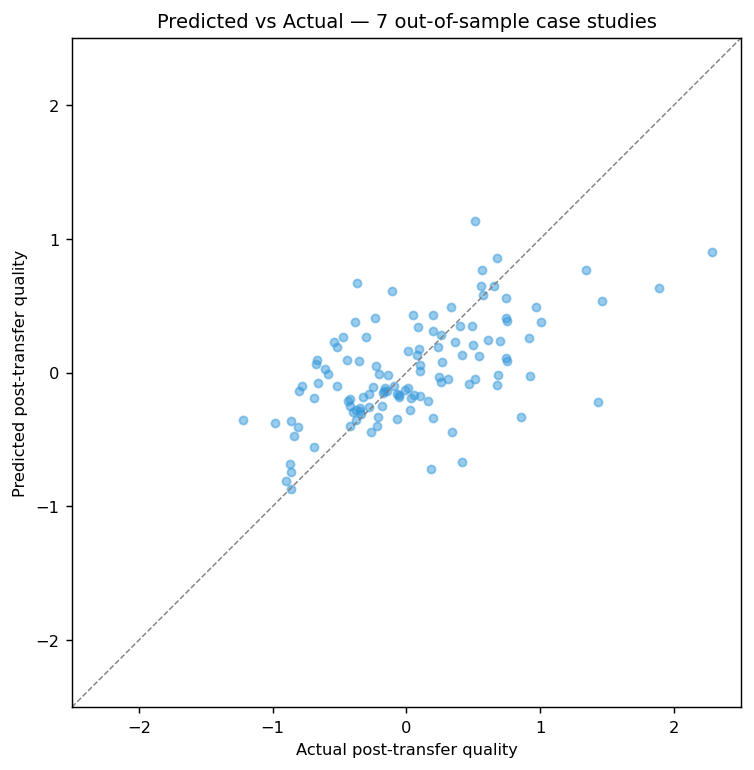

Overall MAE: 0.375


In [86]:
all_preds = []
for c in CASES:
    res = predict_transfer(case_rows[c["wy_id"]]).reset_index()
    res["Player"] = c["name"]
    all_preds.append(res)
all_preds = pd.concat(all_preds, ignore_index=True)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(all_preds["Actual"], all_preds["Predicted"], alpha=0.5, s=20, c="#3498db")
lims = [-2.5, 2.5]
ax.plot(lims, lims, "--", color="grey", linewidth=0.8)
ax.set(xlim=lims, ylim=lims, xlabel="Actual post-transfer quality",
       ylabel="Predicted post-transfer quality",
       title="Predicted vs Actual — 7 out-of-sample case studies")
ax.set_aspect("equal")
fig.tight_layout()
plt.show()

print(f"Overall MAE: {all_preds['Error'].abs().mean():.3f}")